In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


In [2]:
df = pd.read_csv('Black field cricket - records-2025-11-23.csv')
df.head(10)

,Record ID,Data Resource ID,Data Resource Name,Institution ID,Institution,Collection ID,Collection,Licence,Catalogue Number,Event Date,...,Verbatim event date,Basis Of Record,Basis Of Record - original,Occurrence status,Sex,Preparations,Information withheld during processing,Data Generalised during processing,Outlier for layer,Location Quality
0,069a2503-1cfc-4e2e-8722-407eed30251f,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4202469,2019-03-02T23:55:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
1,077a4be0-072f-4b72-a4ae-97d5eb897a5f,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4552569,2024-02-13T00:49:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
2,10c4d5b8-ccf7-4f88-9000-367d8cf0f0ff,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4660240,2025-04-06T02:22:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
3,10fb594e-fd4e-4fd4-b547-73a48187d460,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4664635,2025-04-25T09:13:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
4,12840c9e-20e7-4ec7-8525-b2d088f186a5,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4560036,2024-03-13T04:15:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
5,170988ab-defc-48c9-a9fb-bab336ddea2d,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4663016,2025-04-19T03:14:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
6,17e18bc6-dab0-4010-b6b2-7c1292b09d31,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4250751,2020-02-22T07:12:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
7,193c1f35-d871-48dd-86c9-2b6139220557,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4378317,2021-04-08T04:28:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
8,1d70926a-b270-4923-afb2-e33838a38f15,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4638536,2025-01-09T07:06:00Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True
9,215e622e-a791-46a5-853a-de4cd4be69bd,dr19123,NatureMapr,NaN,NaN,NaN,NaN,CC-BY 3.0 (Au),4561112,2024-03-18T05:23:42Z,...,NaN,HUMAN_OBSERVATION,Human observation,PRESENT,NaN,NaN,NaN,NaN,NaN,True


In [3]:
df.shape
df.columns

Index(['Record ID', 'Data Resource ID', 'Data Resource Name', 'Institution ID',
       'Institution', 'Collection ID', 'Collection', 'Licence',
       'Catalogue Number', 'Event Date', 'taxonConceptID',
       'Scientific Name - original', 'Vernacular name - original',
       'Scientific Name (intepreted)', 'Taxon Rank', 'Vernacular name',
       'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species',
       'Subspecies', 'Institution Code', 'Collection Code', 'Locality',
       'Latitude - original', 'Longitude - original',
       'Geodetic datum - original', 'Decimal latitude (WGS84)',
       'Decimal longitude (WGS84)', 'Geodetic datum', 'Coordinate Precision',
       'Coordinate Uncertainty in Metres', 'Country - parsed',
       'State - parsed', 'Local Government Areas', 'IMCRA Regions',
       'IBRA 7 Regions', 'Minimum Elevation In Metres',
       'Maximum Elevation In Metres', 'Minimum Depth In Meters',
       'Maximum Depth In Meters', 'Individual count', 'Collect

In [4]:
cols_to_drop = [
    'Subspecies',
    'Institution Code',
    'Collection Code',
    'Minimum Elevation In Metres',
    'Maximum Elevation In Metres',
    'Minimum Depth In Meters',
    'Maximum Depth In Meters',
    'Individual count',
    'Basis Of Record',
    'Basis Of Record - original',
    'Occurrence status',
    'Sex',
    'Preparations',
    'Information withheld during processing',
    'Data Generalised during processing',
    'Outlier for layer',
    'Scientific Name - original',
    'Vernacular name - original',
    'Taxon Rank',
    'Kingdom',
    'Phylum',
    'Class',
    'Order',
    'Family',
    'Genus',
    'Species',
    'Year',
    'Month',
    'Day'
]

df = df.drop(columns=cols_to_drop, errors='ignore')



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Record ID                         1324 non-null   object 
 1   Data Resource ID                  1324 non-null   object 
 2   Data Resource Name                1324 non-null   object 
 3   Institution ID                    239 non-null    object 
 4   Institution                       239 non-null    object 
 5   Collection ID                     239 non-null    object 
 6   Collection                        239 non-null    object 
 7   Licence                           1324 non-null   object 
 8   Catalogue Number                  1184 non-null   object 
 9   Event Date                        1255 non-null   object 
 10  taxonConceptID                    1324 non-null   object 
 11  Scientific Name (intepreted)      1324 non-null   object 
 12  Vernac

In [6]:
df['Event Date'] = pd.to_datetime(df['Event Date'], utc=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   Record ID                         1324 non-null   object             
 1   Data Resource ID                  1324 non-null   object             
 2   Data Resource Name                1324 non-null   object             
 3   Institution ID                    239 non-null    object             
 4   Institution                       239 non-null    object             
 5   Collection ID                     239 non-null    object             
 6   Collection                        239 non-null    object             
 7   Licence                           1324 non-null   object             
 8   Catalogue Number                  1184 non-null   object             
 9   Event Date                        1255 non-null   datetime64[ns

In [8]:
df['Month'] = df['Event Date'].dt.month
month_counts = df['Month'].value_counts().sort_index()

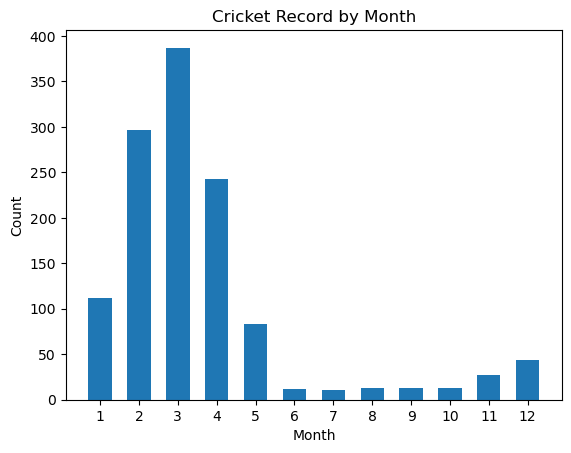

In [9]:
plt.bar(month_counts.index, month_counts.values, width=0.6)
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Cricket Record by Month')
plt.savefig("Cricket_Records_by_month.png", dpi=300, bbox_inches='tight')
plt.show()


In [10]:
unique_years = df['Event Date'].dt.year.dropna().unique()
unique_years_count = len(unique_years)
unique_years, unique_years_count

(array([2019., 2024., 2025., 2020., 2021., 2023., 2015., 2009., 2017.,
        2022., 2018., 1970., 1982., 1983., 1951., 1965., 1979., 1939.,
        2016., 1950., 1963., 1959., 2011., 1928., 1977., 1929., 1938.,
        1964., 1969., 2005., 1949., 1994., 1971., 1975., 1968., 1981.,
        2014., 1948., 1958., 2008., 2013., 1953., 2002., 1967., 1955.,
        1972., 1973., 1911., 1976., 1986., 2001., 2012., 1990., 1952.,
        1978., 2004., 1937., 1960., 2000., 2003., 2006., 1974., 1980.,
        1961., 1984., 1991., 1989., 1999., 2007., 1940., 1985., 1995.,
        2010.]),
 73)

In [11]:
df['Year'] = df['Event Date'].dt.year
year_counts = df['Year'].dropna().astype(int).value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2000]

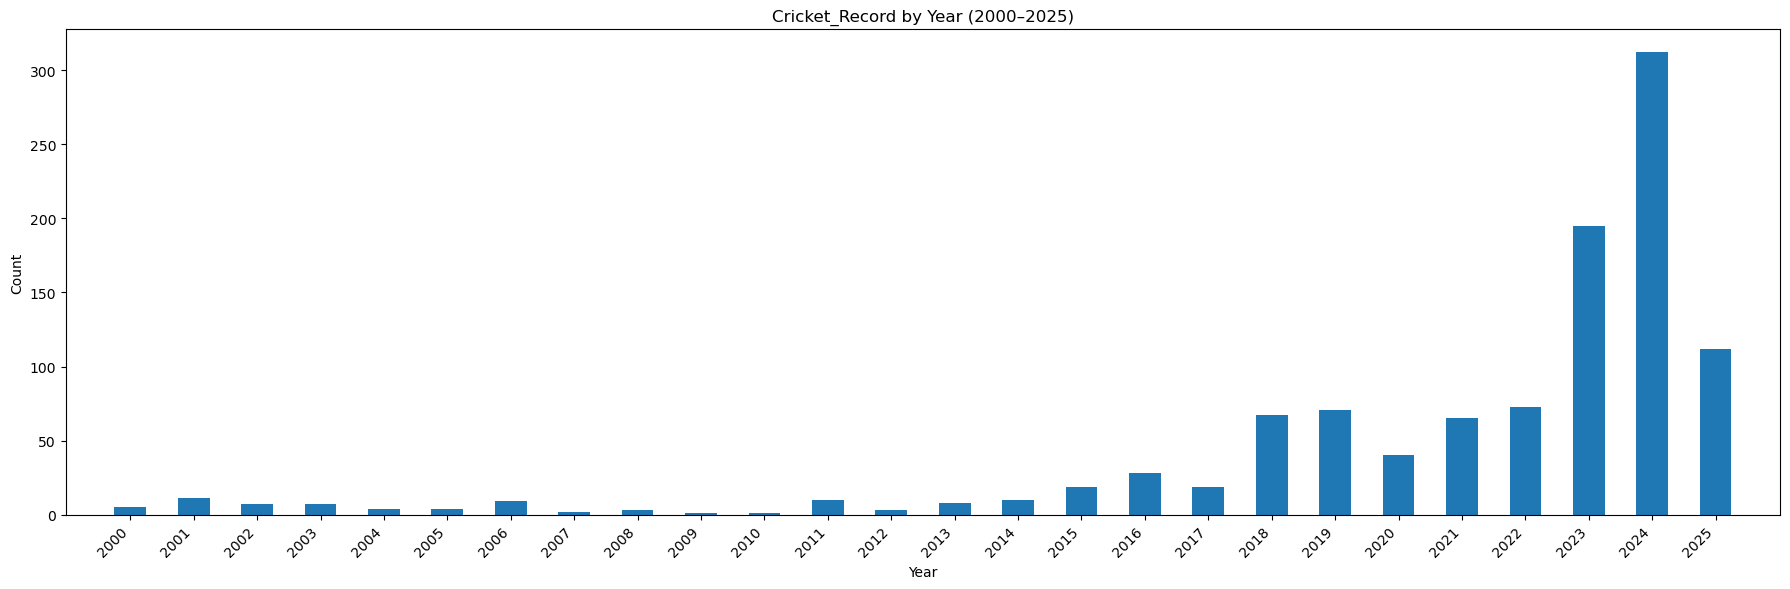

In [12]:
plt.figure(figsize=(18, 6))
plt.bar(year_counts.index, year_counts.values, width=0.5)

plt.margins(x=0.03)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Cricket_Record by Year (2000–2025)")

plt.xticks(year_counts.index, rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Cricket_Record_2000_2025.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
df1 = pd.read_csv('IDCJAC0001_86232_Data12_Rain.csv')
df1.head(10)

,Product code,Station Number,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
0,IDCJAC0001,86232,1964,NaN,NaN,NaN,50.7,75.2,33.3,66.9,60.6,81.7,76.9,37.2,92.2,NaN
1,IDCJAC0001,86232,1965,14.6,0.8,16.3,121.4,80.6,29.8,71.5,100.4,49.6,21.6,66.1,88.8,661.5
2,IDCJAC0001,86232,1966,45.3,48.7,69.0,58.4,47.4,41.0,60.1,65.7,60.0,67.1,47.5,105.9,716.1
3,IDCJAC0001,86232,1967,21.2,3.9,16.6,17.5,47.9,46.1,35.0,68.0,51.5,20.3,20.1,40.1,388.2
4,IDCJAC0001,86232,1968,48.3,6.6,24.6,67.2,100.0,56.9,39.7,40.0,18.3,51.5,44.5,53.6,551.2
5,IDCJAC0001,86232,1969,22.7,126.0,58.9,27.7,135.9,14.2,63.2,32.0,64.8,42.6,42.1,40.7,670.8
6,IDCJAC0001,86232,1970,114.1,16.0,145.8,87.0,90.3,56.5,26.1,72.4,35.2,42.6,67.0,119.7,872.7
7,IDCJAC0001,86232,1971,87.5,94.5,29.9,54.6,81.7,60.8,33.8,43.7,63.2,110.6,157.0,41.3,858.6
8,IDCJAC0001,86232,1972,43.2,238.7,16.8,67.8,34.1,12.6,41.8,44.2,30.5,44.9,48.6,0.8,624.0
9,IDCJAC0001,86232,1973,57.4,211.3,92.3,33.0,71.6,53.3,53.3,66.7,54.2,100.2,68.1,48.8,910.2


In [19]:
month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = df1[month_cols].mean()

In [20]:
rain2023 = df1[df1['Year'] == 2023][month_cols].iloc[0]
rain2024 = df1[df1['Year'] == 2024][month_cols].iloc[0]

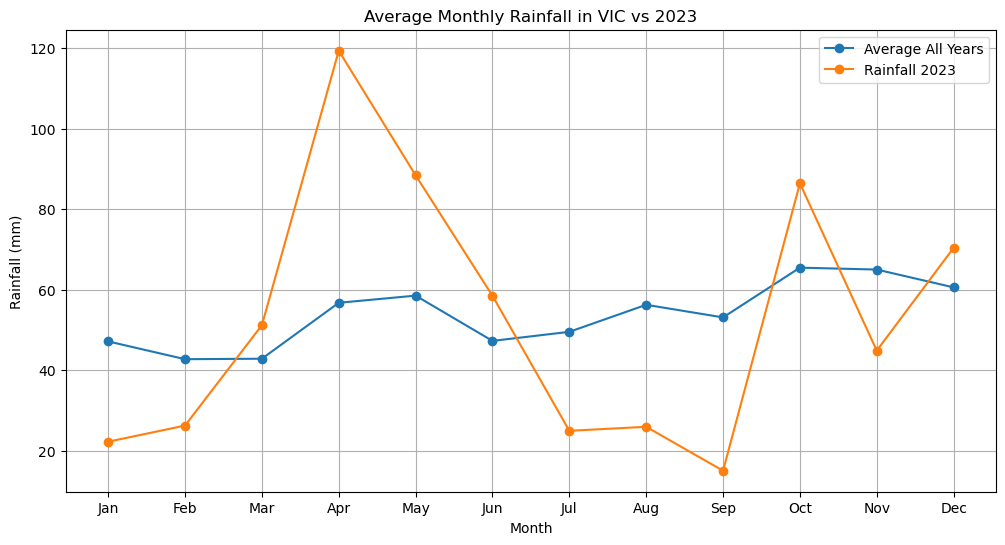

In [21]:
plt.figure(figsize=(12,6))

plt.plot(month_cols, monthly_avg, marker='o', label='Average All Years')

plt.plot(month_cols, rain2023, marker='o', label='Rainfall 2023')

plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.title('Average Monthly Rainfall in VIC vs 2023')
plt.grid(True)
plt.legend()
plt.savefig("Average_Monthly_Rainfall_VIC_vs_2023.png",
            dpi=300, bbox_inches='tight')
plt.show()

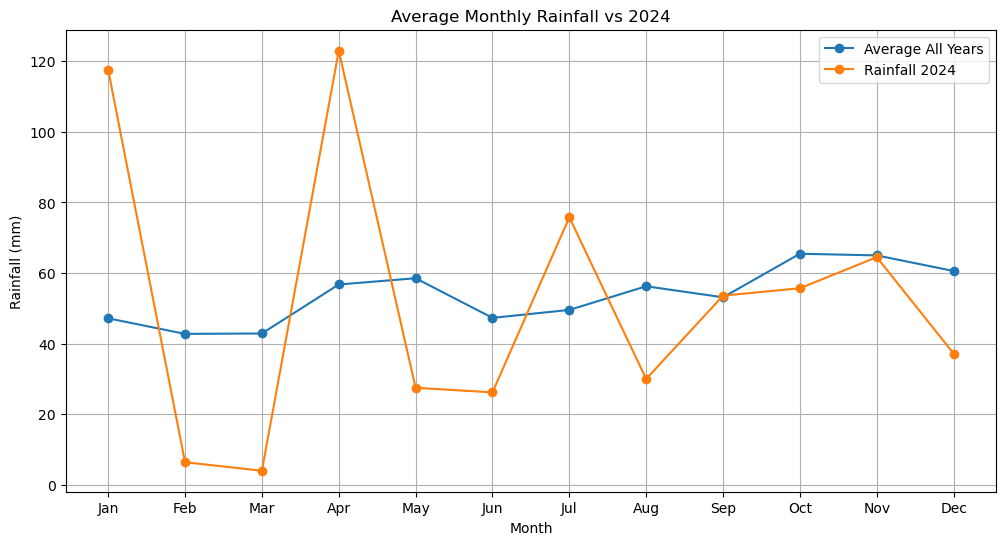

In [22]:
plt.figure(figsize=(12,6))

plt.plot(month_cols, monthly_avg, marker='o', label='Average All Years')
plt.plot(month_cols, rain2024, marker='o', label='Rainfall 2024')


plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.title('Average Monthly Rainfall vs 2024')
plt.grid(True)
plt.legend()
plt.savefig("Average_Monthly_Rainfall_VIC_vs_2024.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [23]:
df2 = pd.read_csv('IDCJAC0002_86038_Data12_temp.csv')
df2.head(10)

,Product code,Station Number,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
0,IDCJAC0002,86038,1939,NaN,NaN,NaN,19.3,16.7,13.3,12.0,13.2,15.9,18.4,20.7,23.6,NaN
1,IDCJAC0002,86038,1940,26.0,25.2,29.2,19.7,16.0,14.0,13.8,16.0,18.2,23.2,20.8,26.0,20.7
2,IDCJAC0002,86038,1941,23.2,25.7,22.0,21.4,16.7,13.6,13.1,14.6,16.4,17.5,22.3,25.1,19.3
3,IDCJAC0002,86038,1942,27.2,26.0,24.9,19.4,16.1,14.4,13.5,15.0,18.0,20.9,22.1,25.8,20.3
4,IDCJAC0002,86038,1943,27.9,25.4,24.7,19.1,16.3,13.1,12.7,13.6,16.0,18.1,20.7,23.2,19.2
5,IDCJAC0002,86038,1944,27.2,25.6,24.6,17.6,14.8,12.7,12.7,13.9,18.5,20.5,22.5,24.7,19.6
6,IDCJAC0002,86038,1945,25.0,23.3,21.2,19.0,16.1,14.4,11.7,14.5,16.3,18.9,23.0,25.3,19.1
7,IDCJAC0002,86038,1946,26.7,24.0,21.2,17.4,16.1,11.9,13.4,13.9,14.6,17.2,21.8,24.4,18.5
8,IDCJAC0002,86038,1947,27.2,28.7,23.9,19.9,19.0,14.2,12.8,13.3,16.8,18.0,19.7,23.3,19.7
9,IDCJAC0002,86038,1948,24.1,26.4,21.6,19.0,14.9,13.2,12.0,15.5,18.1,17.9,20.8,25.0,19.0


In [24]:
month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg_temp = df2[month_cols].mean()

In [25]:
temp2023 = df2[df2['Year'] == 2023][month_cols].iloc[0]
temp2024 = df2[df2['Year'] == 2024][month_cols].iloc[0]

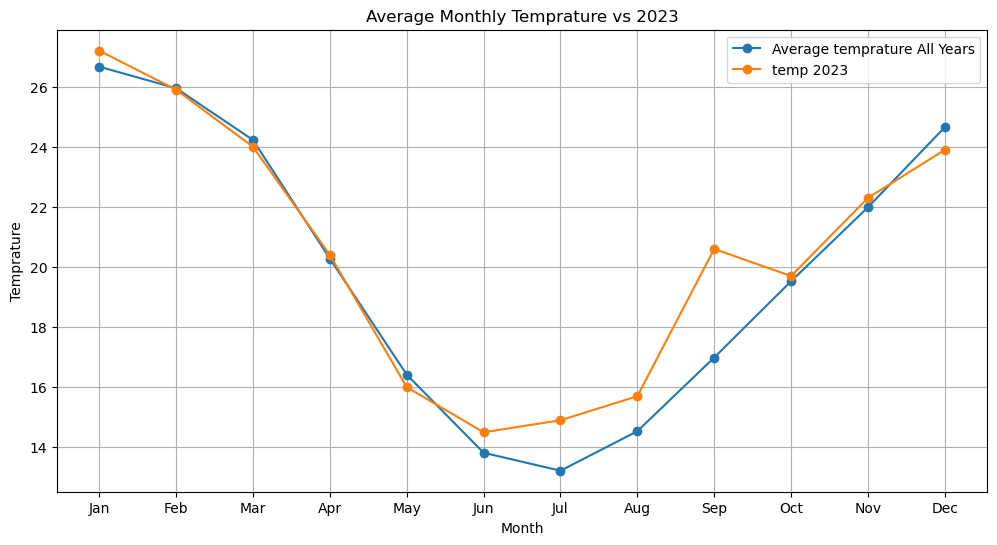

In [26]:
plt.figure(figsize=(12,6))

plt.plot(month_cols, monthly_avg_temp, marker='o', label='Average temprature All Years')
plt.plot(month_cols, temp2023, marker='o', label='temp 2023')

plt.xlabel('Month')
plt.ylabel('Temprature')
plt.title('Average Monthly Temprature vs 2023')
plt.grid(True)
plt.legend()
plt.savefig("Average_Monthly_Temprature_VIC_vs_2023.png",
            dpi=300, bbox_inches='tight')
plt.show()

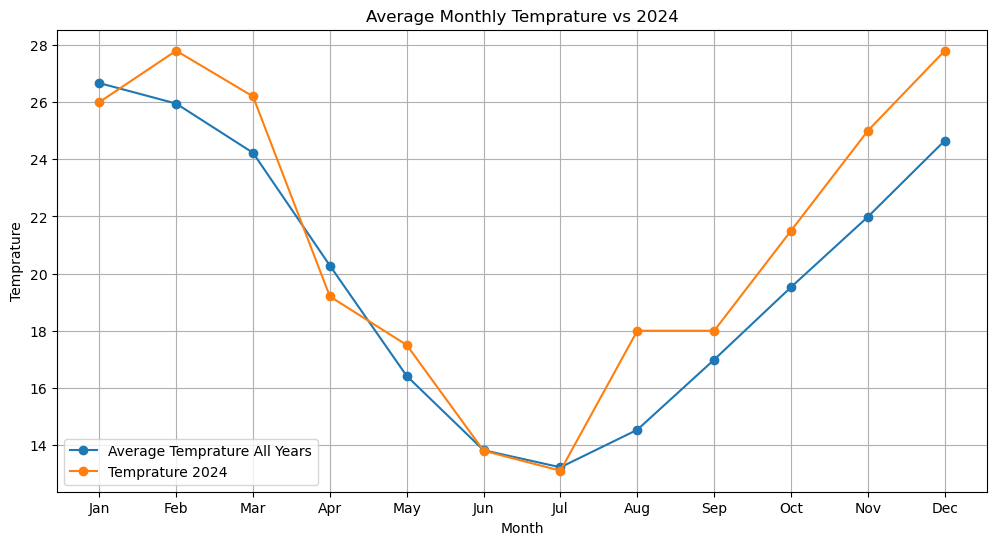

In [27]:
plt.figure(figsize=(12,6))

plt.plot(month_cols, monthly_avg_temp, marker='o', label='Average Temprature All Years')
plt.plot(month_cols, temp2024, marker='o', label='Temprature 2024')

plt.xlabel('Month')
plt.ylabel('Temprature')
plt.title('Average Monthly Temprature vs 2024')
plt.grid(True)
plt.legend()
plt.savefig("Average_Monthly_Temprature_VIC_vs_2024.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [76]:
df_month = pd.read_csv("cricket_monthly_for_rf.csv")
print(df_month.columns)

Index(['Year', 'Month', 'Cricket_Count_Month', 'Rain_Month', 'Temp_Month',
       'Rain_Annual', 'Temp_Annual'],
      dtype='object')


In [91]:
df_month = df_month.sort_values(["Year","Month"])
df_month["Rain_lag1"] = df_month["Rain_Month"].shift(1)
df_month["Rain_lag2"] = df_month["Rain_Month"].shift(2)


# lag4, lag6
df_month["Rain_lag4"] = df_month["Rain_Month"].shift(4)
df_month["Rain_lag6"] = df_month["Rain_Month"].shift(6)

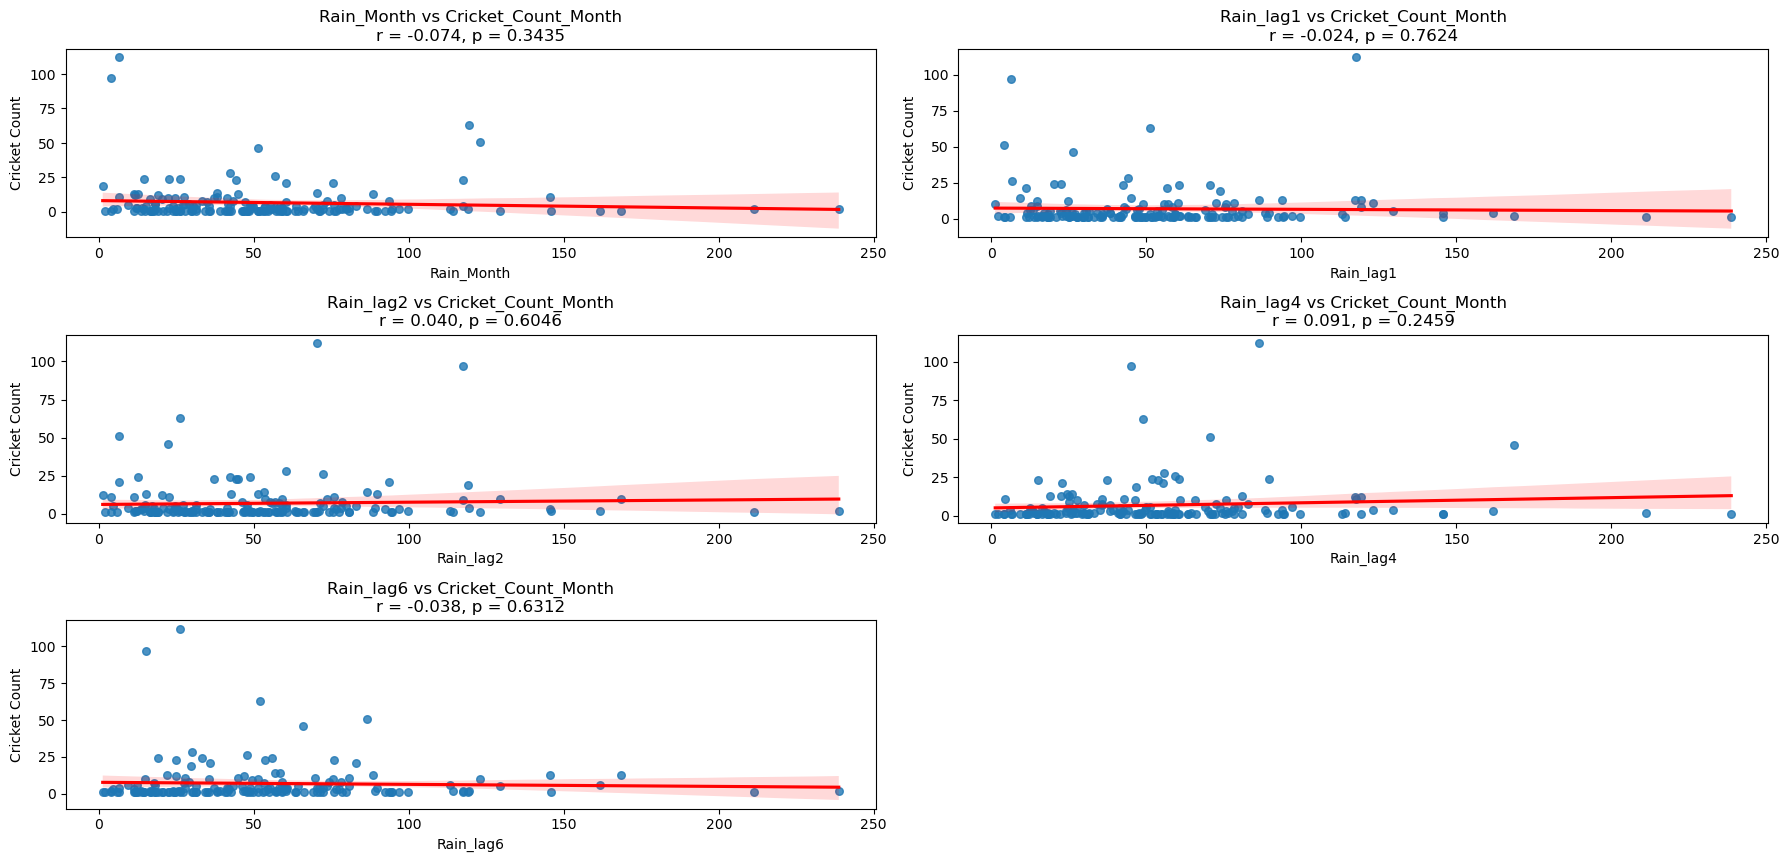

In [93]:
variables = [
    "Rain_Month",
    "Rain_lag1",
    "Rain_lag2",
    "Rain_lag4",
    "Rain_lag6",
]

target  = "Cricket_Count_Month"

plt.figure(figsize=(18, 14))

for i, var in enumerate(variables, 1):
    plt.subplot(5, 2, i) 
    clean_df = df_month[[var, target]].dropna()

    sns.regplot(
        x=clean_df[var],
        y=clean_df[target],
        scatter_kws={'s': 30},
        line_kws={'color': 'red'}
    )

    r, p = pearsonr(clean_df[var], clean_df[target])
    plt.title(f"{var} vs {target}\nr = {r:.3f}, p = {p:.4f}")
    plt.xlabel(var)
    plt.ylabel("Cricket Count")

plt.tight_layout()
plt.show()